In [23]:
import sys
from pathlib import Path

_root = next(p for p in Path.cwd().resolve().parents if (p / '.git').exists() or (p / 'setup.py').exists())
for _p in (str(_root), str(_root / 'src')):
    if _p not in sys.path:
        sys.path.insert(0, _p)

import scanpy as sc
import numpy as np
from metab_processing.metab_travlr_config import DATA_DIR
from metab_processing.LinearRegression.least_squares import (
    fit_gene_betas, rank_coefficients, plot_top_coefficients)

In [24]:
# PATH = f'{DATA_DIR}/Alexi_UC_Spliced/13114_HS1_HC-Slice_1'
PATH = f'{DATA_DIR}/Xenium/Primary_Dermal_Melanoma'
TOP_N = 1000
# ANNOT_COL = '25_06_11_ICI_5K_Coarse_annotations'
ANNOT_COL = 'Tier1'
# CELL_TYPE = 'IEC'
CELL_TYPE = 'T Cell'
METHOD, PENALTY, STANDARDIZE = 'l1', 0.001, True

adata = sc.read_h5ad(Path(PATH) / 'LinearRegression' / f'hvg{TOP_N}_x_adata.h5ad')

In [25]:
# Trained genes, in HVG (most- to least-variable) order.
genes = list(adata.uns['x_genes'])
print(len(genes), 'trained genes')
genes

1000 trained genes


['COL5A1',
 'CXCL9',
 'CD8A',
 'COL5A2',
 'THY1',
 'VGF',
 'COL4A1',
 'POSTN',
 'CD4',
 'ITGB2',
 'CXCL10',
 'IL6',
 'CD3E',
 'THBS1',
 'CXCL13',
 'CD14',
 'SFRP4',
 'MRC1',
 'CD163',
 'SLAMF7',
 'SLC40A1',
 'SOX2-OT',
 'CXCL12',
 'GZMA',
 'COMP',
 'LGMN',
 'IL2RG',
 'MSR1',
 'F13A1',
 'STAB1',
 'PECAM1',
 'PIM2',
 'GIMAP4',
 'CYBB',
 'COL4A2',
 'CCN1',
 'CCND2',
 'CD68',
 'DIO2',
 'DPT',
 'ADAMTS1',
 'CD2',
 'DSG1',
 'GBP5',
 'IKZF1',
 'IRF1',
 'CCDC80',
 'PLVAP',
 'MMP13',
 'SULF1',
 'CD36',
 'MAF',
 'CYBA',
 'FCGR3B',
 'PDGFRB',
 'ANPEP',
 'COL11A1',
 'TNFSF10',
 'ADAM8',
 'WAS',
 'NCF1',
 'MAFB',
 'GAS6',
 'MZB1',
 'PLAU',
 'EVI2B',
 'ADAM12',
 'MAN1A1',
 'CSF1R',
 'LY96',
 'SMOC2',
 'PIM1',
 'IL10RA',
 'OLFML3',
 'ITGAL',
 'CXCR4',
 'NDRG1',
 'MRC2',
 'POU2AF1',
 'LBH',
 'ENPP2',
 'CCL8',
 'PDPN',
 'RASSF5',
 'HECA',
 'SIGLEC1',
 'ARRB2',
 'TLR4',
 'PLAUR',
 'AOAH',
 'SLCO2B1',
 'TMEM45A',
 'CD96',
 'CD302',
 'FMOD',
 'CXCL16',
 'KLRK1',
 'TENT5C',
 'PRRX1',
 'MMP9',
 'CCR1',
 'SA

In [26]:
betas = fit_gene_betas(adata, annot_col=ANNOT_COL, annot_value=CELL_TYPE, source='lognorm',
                       method=METHOD, penalty=PENALTY, standardize=STANDARDIZE)

,gene,factor,group,beta,r,r2,model_r2,n_cells
31003,CD8A,LCK$CD8B,lr,0.107517,0.182988,0.033485,0.096399,9364
158489,S100A1,SP3,tf,0.095538,0.111295,0.012387,0.102356,9364
47649,CXCL9,IL16$CD4,lr,0.089579,0.265006,0.070228,0.198003,9364
145378,POSTN,THY1$ITGB2,lr,0.083769,0.210309,0.044230,0.179247,9364
158599,S100A1,DLL3$NOTCH1,lr,0.075238,0.142143,0.020205,0.102356,9364
109459,LIPA,IL16$CD4,lr,0.070394,0.258433,0.066787,0.163808,9364
47625,CXCL9,CXCL11$CXCR3,lr,0.067351,0.107344,0.011523,0.198003,9364
45323,CTSC,IL16$CD4,lr,0.057975,0.247104,0.061060,0.148869,9364
28398,CD3E,IL15$IL2RG,lr,0.055838,0.195284,0.038136,0.136905,9364
158488,S100A1,RARA,tf,0.055739,0.039513,0.001561,0.102356,9364


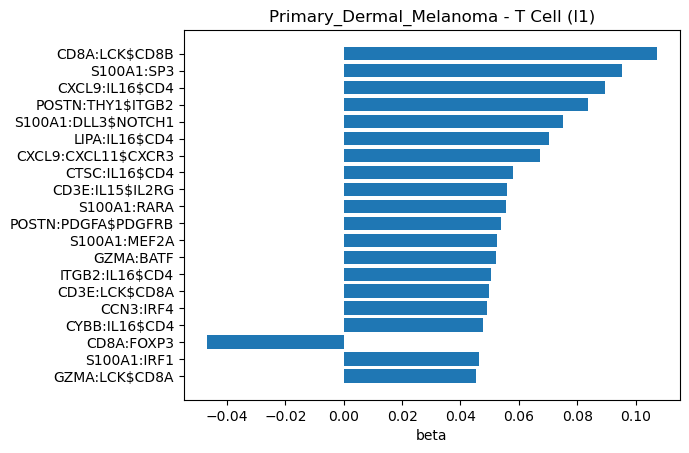

In [27]:
display(rank_coefficients(betas).head(50))
plot_top_coefficients(betas, top=20).set_title(f'{Path(PATH).name} - {CELL_TYPE} ({METHOD})');

In [28]:
rank_coefficients(betas[betas['gene'] == '']).head(20)

,gene,factor,group,beta,r,r2,model_r2,n_cells


In [29]:
rank_coefficients(betas[betas['factor'] == 'JUN']).head(20)

,gene,factor,group,beta,r,r2,model_r2,n_cells


In [30]:
np.sum(betas['beta'] != 0)

np.int64(79444)

In [31]:
np.sum(betas['group'] != 'metab')

np.int64(202389)

In [32]:
betas['r']

0         0.027711
1         0.048146
2         0.014314
3         0.028574
4        -0.006953
            ...   
202384    0.021487
202385    0.091076
202386    0.007010
202387    0.023736
202388    0.053433
Name: r, Length: 202389, dtype: float64

In [33]:
np.sum(betas['beta'] != 0) / np.sum(betas['group'] != 'metab')

np.float64(0.3925312146411119)